In [1]:
import pandas as pd
import re

# === 1. Charger les données ===
df = pd.read_csv("Les_réponses.csv", encoding="utf-8")
df = df.drop(columns=["Horodateur"])

# === 2. Renommer les colonnes ===
df = df.rename(columns={
    'Quelles sont les principales difficultés que vous rencontrez pour trouver un emploi ?  ': 'difficulte_declares',
    'votre spécialité ': 'specialite',
    'Dans quelle ville recherchez vous principalement un emploi ?  ': 'ville',
    'Selon vous, quel est le salaire minimum que vous seriez prêt à accepter pour un tel emploi ? (en dh)': 'salaire_min_acceptable',
    'Votre genre': 'genre',
    'Votre Age ': 'age',
    'Niveau académique': 'niveau_academique',
    ' Avez-vous déjà effectué un stage   ': 'a_fait_stage',
    'Êtes-vous actuellement en recherche d’emploi ?  ': 'cherche_emploi'
})

# === 3. Nettoyage général ===
df = df.dropna(how='all')
df = df.applymap(lambda x: x.replace("’", "'").strip() if isinstance(x, str) else x)
df['ville'] = df['ville'].str.lower().str.strip()
df['specialite'] = df['specialite'].str.lower().str.strip()
df['salaire_min_acceptable'] = pd.to_numeric(df['salaire_min_acceptable'], errors='coerce')

# === 4. Nettoyage des villes et ajout de la région ===
ville_mapping = {
    r'casablanca|casa blanche|casa|الدار البيضاء': 'Casablanca',
    r'rabat.*|rabat/.*': 'Rabat',
    r'kenitra|kénitra': 'Kénitra',
    r'salé|sale': 'Salé',
    r'marrakech': 'Marrakech',
    r'tanger': 'Tanger',
    r'agadir': 'Agadir',
    r'el ?jadida|jdida': 'El Jadida',
    r'fes|fès': 'Fès',
    r'meknes|meknès': 'Meknès',
    r'safi': 'Safi',
    r'temara': 'Temara',
    r'al hoceima': 'Al Hoceima',
    r'dakhla': 'Dakhla',
    r'sidi slimane|sidi sliman': 'Sidi Slimane',
    r'khenifra': 'Khénifra',
    r'ben hmed|ben ahmed': 'Ben Ahmed',
    r'paris|hors maroc': 'Étranger',
    r'\.\.\.|maroc|^$': 'Non spécifié'
}

def nettoyer_ville(ville):
    if pd.isna(ville) or ville.strip() == "":
        return "Non spécifié"
    for pattern, nom in ville_mapping.items():
        if re.search(pattern, ville, re.IGNORECASE):
            return nom
    return ville.title()

df['ville'] = df['ville'].apply(nettoyer_ville)

region_mapping = {
    'Casablanca': 'Casablanca-Settat',
    'Rabat': 'Rabat-Salé-Kénitra',
    'Salé': 'Rabat-Salé-Kénitra',
    'Kénitra': 'Rabat-Salé-Kénitra',
    'Temara': 'Rabat-Salé-Kénitra',
    'Marrakech': 'Marrakech-Safi',
    'Tanger': 'Tanger-Tétouan-Al Hoceima',
    'Agadir': 'Souss-Massa',
    'Fès': 'Fès-Meknès',
    'Meknès': 'Fès-Meknès',
    'El Jadida': 'Casablanca-Settat',
    'Safi': 'Marrakech-Safi',
    'Al Hoceima': 'Tanger-Tétouan-Al Hoceima',
    'Dakhla': 'Dakhla-Oued Ed-Dahab',
    'Sidi Slimane': 'Rabat-Salé-Kénitra',
    'Khénifra': 'Béni Mellal-Khénifra',
    'Ben Ahmed': 'Casablanca-Settat',
    'Étranger': 'Étranger',
    'Non spécifié': 'Non spécifié'
}

df['region'] = df['ville'].map(region_mapping)

# === 5. Catégorisation du salaire minimum accepté ===
bins = [0, 1000, 2000, 3000, 5000, 10000]
labels = ['<1000', '1000-2000', '2000-3000', '3000-5000', '>5000']
df['cat_salaire_min'] = pd.cut(df['salaire_min_acceptable'], bins=bins, labels=labels, right=False)

# === 6. Regroupement des spécialités ===
specialite_mapping = {
    r'math(é|e)matique': 'Sciences fondamentales',
    r'physique et chimie': 'Sciences fondamentales',
    r'science de la vie et de la terre': 'Sciences fondamentales',
    r'informatique.*(données|data)': 'Informatique & Data Science',
    r'cyber ?security': 'Informatique & Data Science',
    r'science math.* informatique': 'Informatique & Data Science',
    r'(é|e)conomie': 'Sciences économiques & Gestion',
    r'finance': 'Sciences économiques & Gestion',
    r'management bancaire': 'Sciences économiques & Gestion',
    r'g(e|é)nie.*|agronomie|agriculture|logistique': 'Ingénierie & Technologie',
    r'maritime|marin|navales': 'Sciences maritimes',
    r'psychologie clinique': 'Psychologie clinique',
    r'psychologie': 'Sciences humaines & Sociales',
    r'sociologie|sosciologie': 'Sciences humaines & Sociales',
    r'droit': 'Sciences humaines & Sociales',
    r'journalisme': 'Sciences humaines & Sociales',
    r'lang(ue|age)s|traduction|litt(é|e)rature|fran(c|ç)ais': 'Langues & Littérature',
    r'crmef|cfe': 'Éducation & Formation',
    r'infirmi(e|è)re|m(e|é)decine': 'Santé',
    r'architecture': 'Architecture',
    r'management': 'Management'
}

def regrouper_specialite(specialite):
    for pattern, domaine in specialite_mapping.items():
        if re.search(pattern, specialite, re.IGNORECASE):
            return domaine
    return 'Autre'

df['specialite'] = df['specialite'].apply(regrouper_specialite)

# === 7. Standardiser niveau académique ===
niveau_mapping = {
    r'licence|Bac \+3|3année licence': 'Licence',
    r'Master|Bac \+5': 'Master',
    r'Doctorat|Bac \+8': 'Doctorat',
    r'CRMEF|CFE|Diplome des infirmiers': 'Diplôme professionnel',
    r'Ing(e|é)nieur|Cycle d’ing(e|é)nieur|Ing(e|é)nieur d’état': 'Cycle ingénieur',
    r'Bac|Baccalaur(e|é)at': 'Baccalauréat',
    r'Bac \+2|Back\+ 2|CPGE|Cycle pr(e|é)paratoire|prepa': 'Bac+2/Prépa',
    r'1(e|è)re ann(e|é)e|En cours': 'En cours de formation'
}

def standardiser_niveau(niveau):
    if pd.isna(niveau) or str(niveau).strip() == "":
        return "Non spécifié"
    for pattern, cat in niveau_mapping.items():
        if re.search(pattern, niveau, re.IGNORECASE):
            return cat
    return niveau

df['niveau'] = df['niveau_academique'].apply(standardiser_niveau)

# === 8. Encoder les difficultés ===
def contient_expression(texte, expressions):
    if pd.isna(texte):
        return False
    texte = texte.lower().replace("’", "'")
    return any(expr in texte for expr in expressions)

df['manque_experience'] = df['difficulte_declares'].apply(lambda x: contient_expression(x, ["manque d'expérience", "pas d'expérience", "aucune expérience"]))
df['competences_non_adaptees'] = df['difficulte_declares'].apply(lambda x: contient_expression(x, ["compétences non adaptées", "pas les compétences"]))
df['peu_offres'] = df['difficulte_declares'].apply(lambda x: contient_expression(x, ["peu d'offres", "offres limitées"]))
df['salaire_faible'] = df['difficulte_declares'].apply(lambda x: contient_expression(x, ["salaire faible", "rémunération insuffisante", "salaire bas"]))

# === 9. Supprimer les colonnes fusionnées inutiles ===
df = df.drop(columns=['niveau_academique'])
df = df.drop(columns=['ville'])
# === 10. Sauvegarde finale ===
df.to_csv("Réponses_nettoyees_et_regroupees.csv", index=False)



/tmp/ipykernel_7305/3578588205.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.replace("’", "'").strip() if isinstance(x, str) else x)


<>:9: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_7305/1804153712.py:9: SyntaxWarning: invalid escape sequence '\['
  df["Age (tranche)"] = df["Votre Age "].str.replace("[\[\]]", "", regex=True)


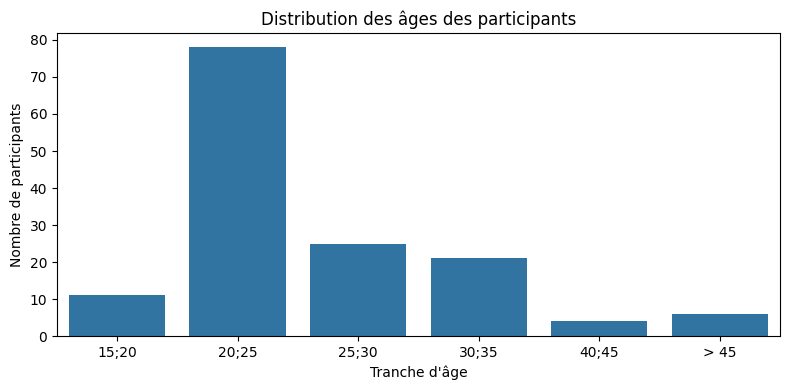

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv("Les_réponses.csv")

# Nettoyage éventuel : suppression des crochets et conversion en tranche
df["Age (tranche)"] = df["Votre Age "].str.replace("[\[\]]", "", regex=True)

# Tracer l'histogramme des tranches d'âge
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Age (tranche)", order=sorted(df["Age (tranche)"].unique()))
plt.title("Distribution des âges des participants")
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre de participants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


/tmp/ipykernel_7305/2012239382.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="genre", palette="Set2")


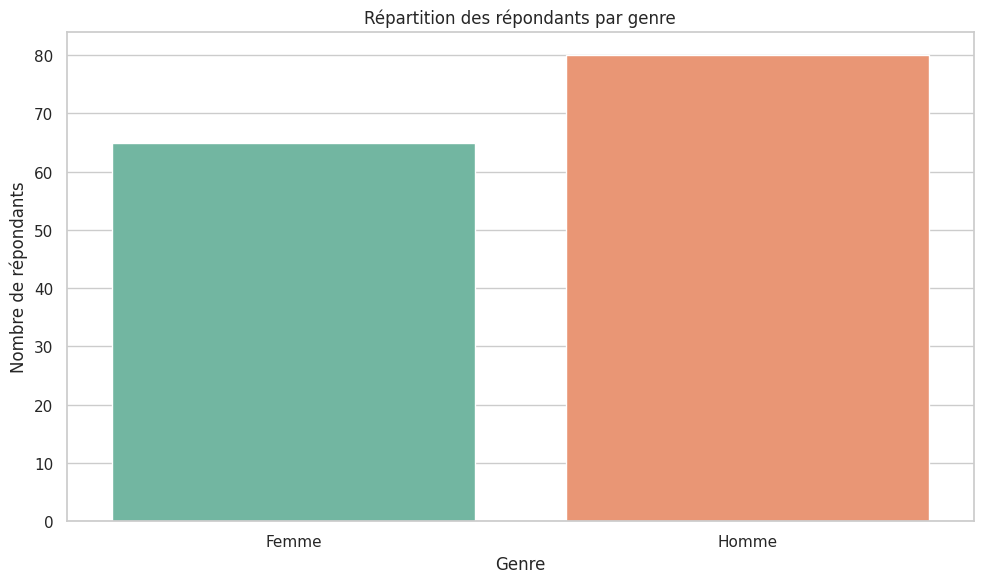

/tmp/ipykernel_7305/2012239382.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="niveau", palette="Set3")


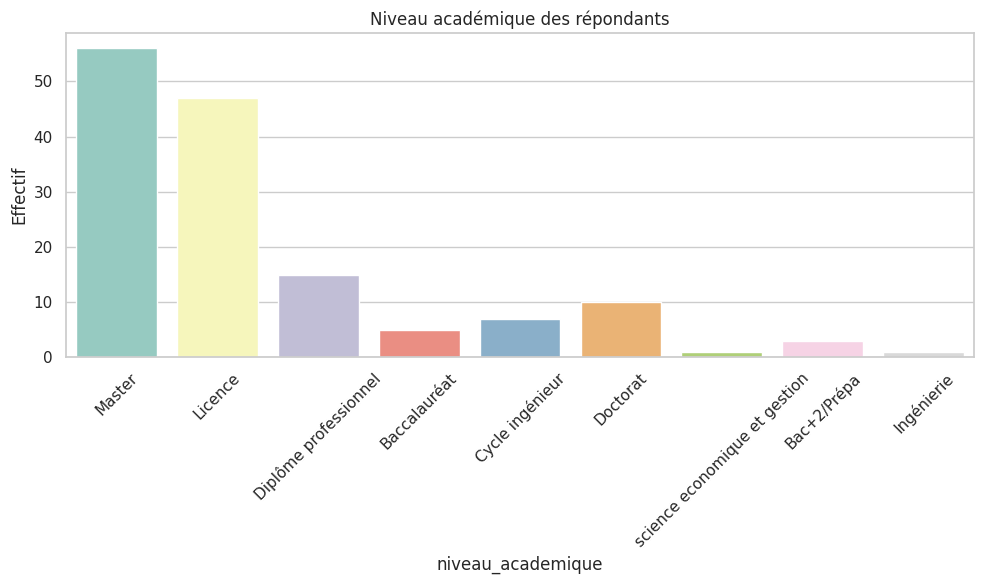

/tmp/ipykernel_7305/2012239382.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="region", order=df['region'].value_counts().index, palette="coolwarm")


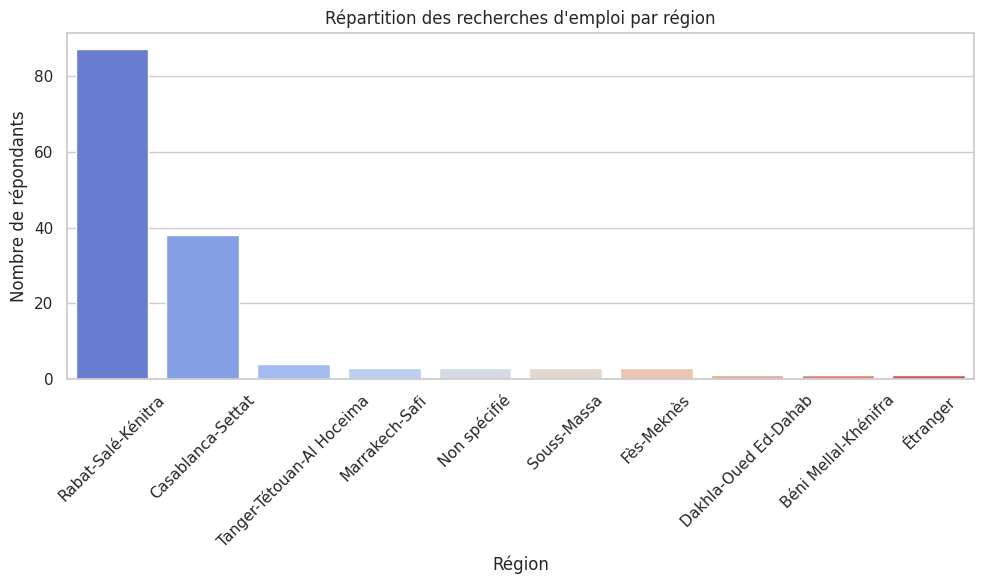

/tmp/ipykernel_7305/2012239382.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="cat_salaire_min", palette="viridis")


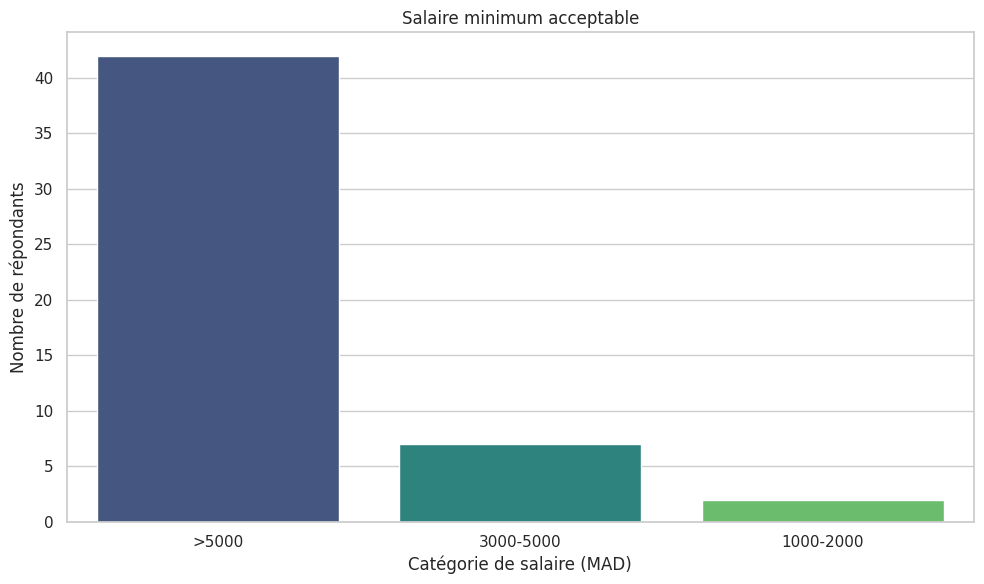

/tmp/ipykernel_7305/2012239382.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=experience_by_genre.index, y=experience_by_genre.values, palette="Set1")


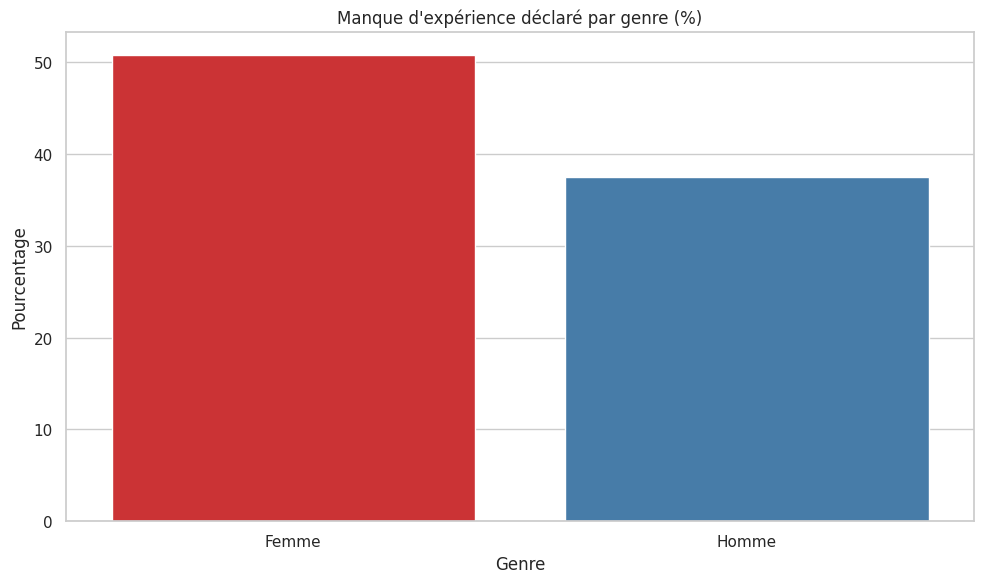

/tmp/ipykernel_7305/2012239382.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=peu_offres_par_region.index, y=peu_offres_par_region.values, palette="Set2")


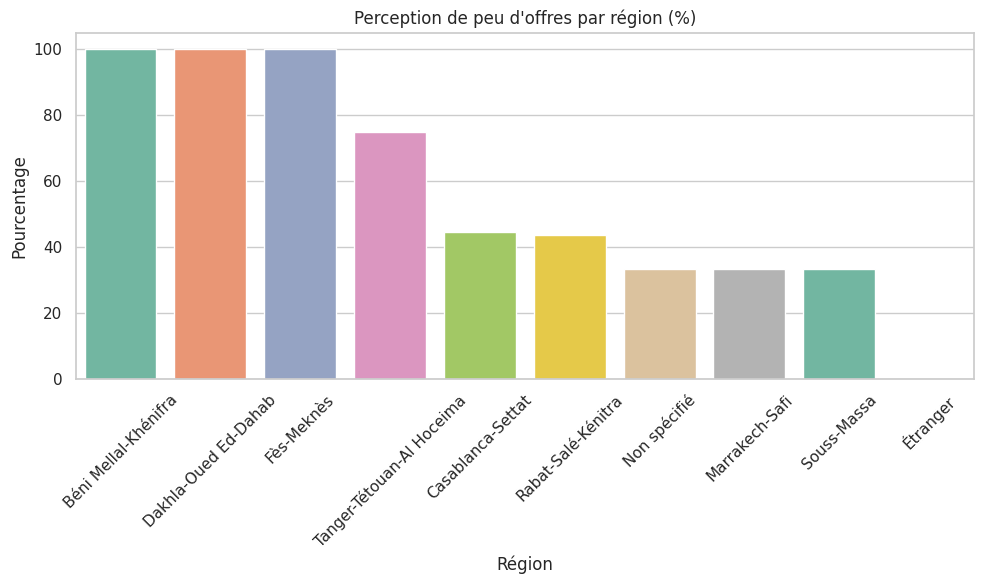

/tmp/ipykernel_7305/2012239382.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exp_par_stage.index, y=exp_par_stage.values, palette="Set3")


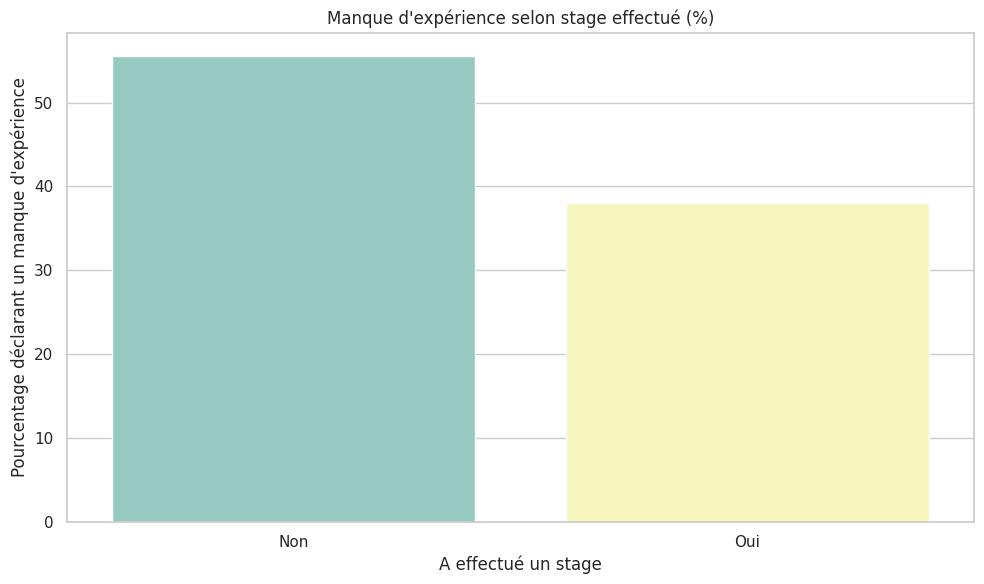

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données nettoyées
df = pd.read_csv("Réponses_nettoyees_et_regroupees.csv")

# Configurations esthétiques
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Répartition par genre
plt.figure()
sns.countplot(data=df, x="genre", palette="Set2")
plt.title("Répartition des répondants par genre")
plt.xlabel("Genre")
plt.ylabel("Nombre de répondants")
plt.tight_layout()
plt.show()

# 2. Niveau académique
plt.figure()
sns.countplot(data=df, x="niveau", palette="Set3")
plt.title("Niveau académique des répondants")
plt.xlabel("niveau_academique")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Répartition géographique
plt.figure()
sns.countplot(data=df, x="region", order=df['region'].value_counts().index, palette="coolwarm")
plt.title("Répartition des recherches d'emploi par région")
plt.xlabel("Région")
plt.ylabel("Nombre de répondants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Catégories de salaire
plt.figure()
sns.countplot(data=df, x="cat_salaire_min", palette="viridis")
plt.title("Salaire minimum acceptable")
plt.xlabel("Catégorie de salaire (MAD)")
plt.ylabel("Nombre de répondants")
plt.tight_layout()
plt.show()

# 5. Manque d’expérience par genre
experience_by_genre = df.groupby("genre")["manque_experience"].mean().sort_values(ascending=False) * 100
plt.figure()
sns.barplot(x=experience_by_genre.index, y=experience_by_genre.values, palette="Set1")
plt.title("Manque d'expérience déclaré par genre (%)")
plt.ylabel("Pourcentage")
plt.xlabel("Genre")
plt.tight_layout()
plt.show()

# 6. Peu d'offres par région
peu_offres_par_region = df.groupby("region")["peu_offres"].mean().sort_values(ascending=False) * 100
plt.figure()
sns.barplot(x=peu_offres_par_region.index, y=peu_offres_par_region.values, palette="Set2")
plt.title("Perception de peu d'offres par région (%)")
plt.ylabel("Pourcentage")
plt.xlabel("Région")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Manque d’expérience vs stage
exp_par_stage = df.groupby("a_fait_stage")["manque_experience"].mean() * 100
plt.figure()
sns.barplot(x=exp_par_stage.index, y=exp_par_stage.values, palette="Set3")
plt.title("Manque d'expérience selon stage effectué (%)")
plt.xlabel("A effectué un stage")
plt.ylabel("Pourcentage déclarant un manque d'expérience")
plt.tight_layout()
plt.show()


peu_offres                  45.517241
manque_experience           43.448276
salaire_faible              33.793103
competences_non_adaptees    22.758621
dtype: float64


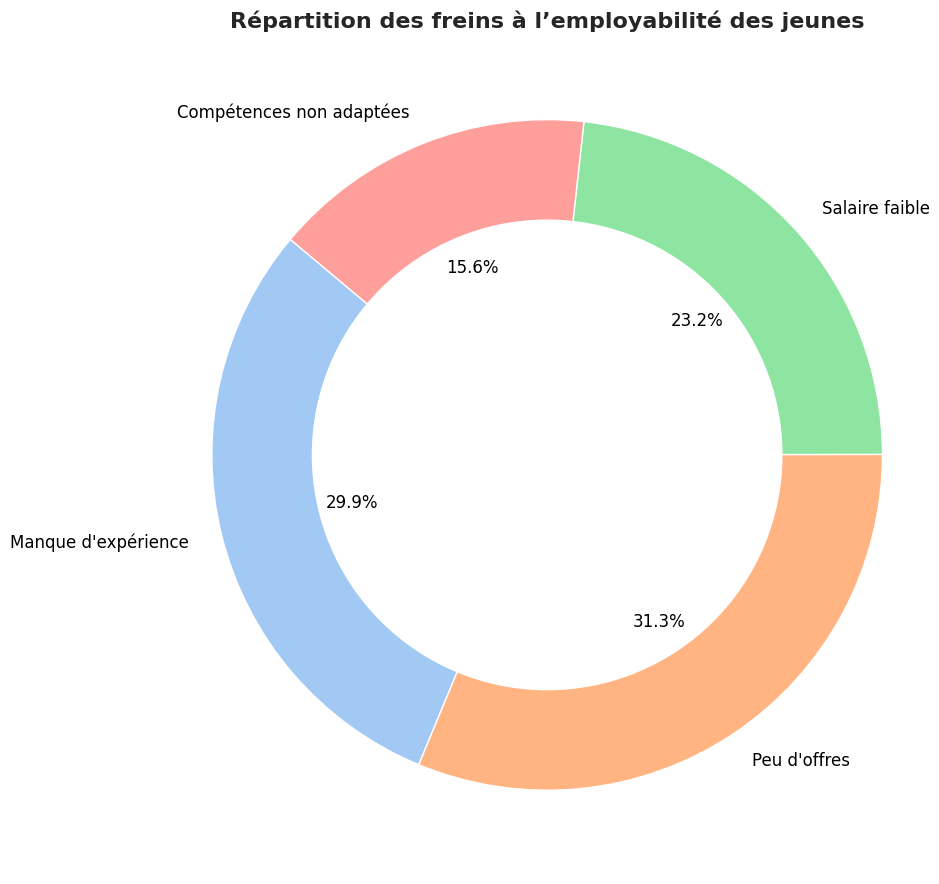

In [4]:
#test de fiabilité des hypotheses
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Réponses_nettoyees_et_regroupees.csv")

#H1
print(df[['peu_offres', 'manque_experience', 'salaire_faible', 'competences_non_adaptees']].mean()*100)

  #histogramme de visualisation 
freins = ['manque_experience', 'peu_offres', 'salaire_faible', 'competences_non_adaptees']
labels = ['Manque d\'expérience', 'Peu d\'offres', 'Salaire faible', 'Compétences non adaptées']

# Calcul des pourcentages
frein_counts = df[freins].sum()
frein_pourcentages = (frein_counts / len(df)) * 100

# Couleurs modernes depuis seaborn
couleurs = sns.color_palette("pastel")

# Création du camembert
plt.figure(figsize=(9, 9))
wedges, texts, autotexts = plt.pie(
    frein_pourcentages,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=couleurs,
    textprops={'fontsize': 12, 'color': 'black'}
)

# Titre stylisé
plt.title("Répartition des freins à l’employabilité des jeunes", fontsize=16, weight='bold')

# Cercle central pour un effet donut léger (optionnel)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Affichage
plt.tight_layout()
plt.axis('equal')
plt.show()
  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
df = pd.read_csv("Réponses_analysees.csv")
villes_rurales = ['Sidi Slimane', 'Khénifra', 'Ben Ahmed']
df['zone'] = df['ville'].apply(
    lambda x: 'Rurale' if str(x) in villes_rurales else 'Urbaine'
)



# 2. La colonne 'peu_offres' est déjà binaire (True si "peu d'offres" mentionné)
# Si ce n’est pas déjà le cas, crée-la :
expr_peu_offres = ['peu d\'offres', 'offres limitées']
df['peu_offres'] = df['difficulte_declares'].apply(lambda x: any(e in str(x).lower() for e in expr_peu_offres))

# 3. Créer la table de contingence
table = pd.crosstab(df['zone'], df['peu_offres'])
table.columns = ['Ne mentionne pas', 'Mentionne']
print("📊 Table de contingence :\n", table)

# 4. Test du Chi²
chi2, p, dof, expected = chi2_contingency(table)
print(f"\n Statistique du Chi² : {chi2:.2f}")
print(f" p-value : {p:.4f}")

📊 Table de contingence :
          Ne mentionne pas  Mentionne
zone                                
Urbaine                79         66

 Statistique du Chi² : 0.00
 p-value : 1.0000


Table de contingence :
peu_offres                     False  True 
niveau                                     
Bac+2/Prépa                        3      0
Baccalauréat                       4      1
Cycle ingénieur                    2      5
Diplôme professionnel             10      5
Doctorat                           2      8
Ingénierie                         0      1
Licence                           23     24
Master                            35     21
science economique et gestion      0      1

Résultats du test du Chi² :
Chi² : 15.84
Degrés de liberté : 8
Valeur p : 0.0448
👉 On rejette l'hypothèse H0 : le niveau académique influence la citation du manque d'offres.


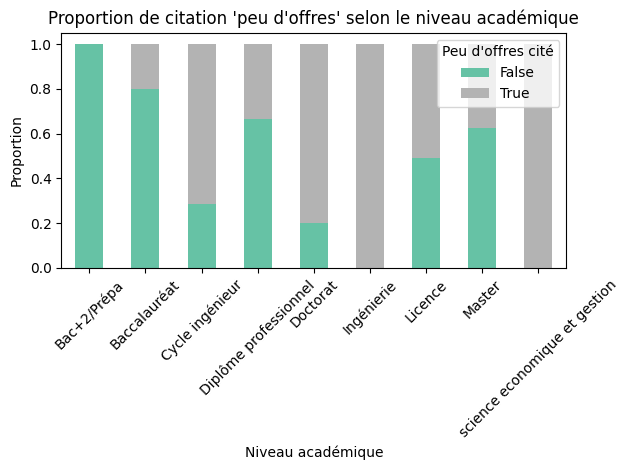

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le fichier nettoyé
df = pd.read_csv('Réponses_nettoyees_et_regroupees.csv')


# Supprimer les valeurs manquantes
df_test = df[['niveau', 'peu_offres']].dropna()

# Table de contingence
contingence = pd.crosstab(df_test['niveau'], df_test['peu_offres'])

# Affichage de la table
print("Table de contingence :")
print(contingence)

# Test du chi2
chi2, p, dof, expected = chi2_contingency(contingence)

# Résultats
print("\nRésultats du test du Chi² :")
print(f"Chi² : {chi2:.2f}")
print(f"Degrés de liberté : {dof}")
print(f"Valeur p : {p:.4f}")

# Conclusion
alpha = 0.05
if p < alpha:
    print("👉 On rejette l'hypothèse H0 : le niveau académique influence la citation du manque d'offres.")
else:
    print(" On ne rejette pas H0 : le niveau académique n'a pas d'effet significatif.")

# Visualisation
contingence_norm = contingence.div(contingence.sum(axis=1), axis=0)
contingence_norm.plot(kind='bar', stacked=True, colormap='Set2')
plt.title("Proportion de citation 'peu d'offres' selon le niveau académique")
plt.xlabel("Niveau académique")
plt.ylabel("Proportion")
plt.legend(title="Peu d'offres cité")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Table de contingence :
                       Ne mentionne pas  Mentionne
A fait un stage                      40         33
N'a pas fait de stage                19         22


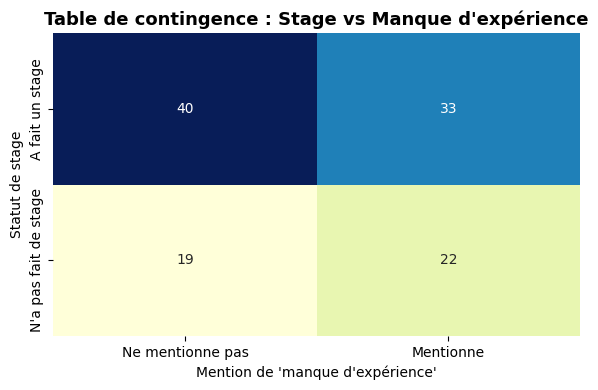

 la p valeur est  :  0.5019003155983004


In [ ]:
#test de fiabilité des hypotheses
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Réponses_nettoyees_et_regroupees.csv")
# Table de contingence brute
jeunes = df[df['age'].isin(['[15;20[', '[20;25[', '[25;30['])]
contingency_table = pd.crosstab(
    jeunes['a_fait_stage'] == 'Non',
    jeunes['difficulte_declares'].str.contains("Manque d'expérience", case=False)
)

contingency_table.index = ['A fait un stage', "N'a pas fait de stage"]
contingency_table.columns = ['Ne mentionne pas', 'Mentionne']

print("Table de contingence :")
print(contingency_table)
plt.figure(figsize=(6, 4))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', cbar=False)

plt.title("Table de contingence : Stage vs Manque d'expérience", fontsize=13, weight='bold')
plt.xlabel("Mention de 'manque d'expérience'")
plt.ylabel("Statut de stage")
plt.tight_layout()
plt.show()

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(" la p valeur est  : ",p)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
from scipy.stats import chi2_contingency
from scipy import stats
# 1. Charger les données
df = pd.read_csv('Réponses_nettoyees_et_regroupees.csv')

# 2. Nettoyage : filtrer genres valides + salaires valides
df_h5 = df[['genre', 'salaire_min_acceptable']].dropna()
df_h5 = df_h5[df_h5['genre'].isin(['Homme', 'Femme'])]

# 3. Séparer les groupes
hommes = df_h5[df_h5['genre'] == 'Homme']['salaire_min_acceptable']
femmes = df_h5[df_h5['genre'] == 'Femme']['salaire_min_acceptable']

# 4. Visualisation





Table de contingence :
competences_non_adaptees  False  True 
est_scientifique                      
False                        22      5
True                         90     28

Résultat du test du Chi² :
Statistique Chi² : 0.11
p-value : 0.7428
❌ On ne rejette pas H0 : pas de lien significatif détecté.


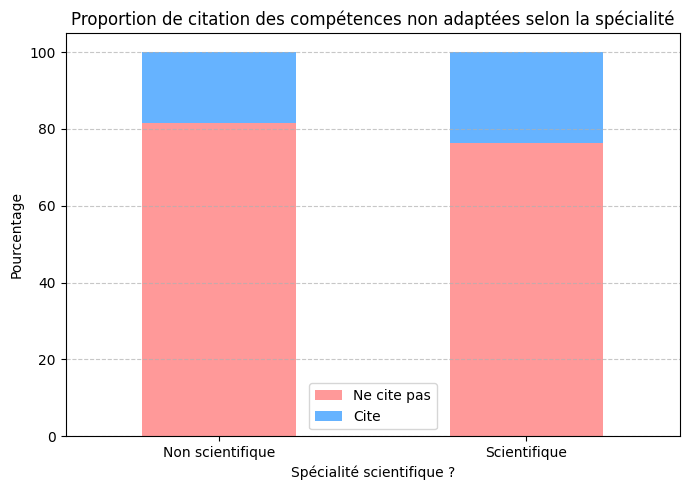

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Charger les données
df = pd.read_csv("Réponses_nettoyees_et_regroupees.csv")

# Définir les spécialités scientifiques
scientifiques = [
    "Sciences fondamentales", 
    "Informatique & Data Science", 
    "Ingénierie & Technologie", 
    "Santé", 
    "Architecture"
]

# Créer une nouvelle colonne booléenne : spécialité scientifique ou non
df['est_scientifique'] = df['specialite'].isin(scientifiques)

# Table de contingence
contingence = pd.crosstab(df['est_scientifique'], df['competences_non_adaptees'])

print("Table de contingence :")
print(contingence)

# Test du chi²
chi2, p, dof, expected = chi2_contingency(contingence)

print("\nRésultat du test du Chi² :")
print(f"Statistique Chi² : {chi2:.2f}")
print(f"p-value : {p:.4f}")

if p < 0.05:
    print("✅ On rejette H0 : les spécialités scientifiques sont significativement associées à la citation de compétences non adaptées.")
else:
    print("❌ On ne rejette pas H0 : pas de lien significatif détecté.")

# 📊 Visualisation
pourcentages = contingence.div(contingence.sum(axis=1), axis=0) * 100
pourcentages.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], figsize=(7,5))

plt.title("Proportion de citation des compétences non adaptées selon la spécialité")
plt.xlabel("Spécialité scientifique ?")
plt.ylabel("Pourcentage")
plt.xticks([0,1], ['Non scientifique', 'Scientifique'], rotation=0)
plt.legend(["Ne cite pas", "Cite"])
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


🔍 Résultats pour manque_experience :
              precision    recall  f1-score   support

       False       0.48      0.73      0.58        15
        True       0.33      0.14      0.20        14

    accuracy                           0.45        29
   macro avg       0.41      0.44      0.39        29
weighted avg       0.41      0.45      0.40        29

🔍 Résultats pour competences_non_adaptees :
              precision    recall  f1-score   support

       False       0.86      0.96      0.91        25
        True       0.00      0.00      0.00         4

    accuracy                           0.83        29
   macro avg       0.43      0.48      0.45        29
weighted avg       0.74      0.83      0.78        29

🔍 Résultats pour peu_offres :
              precision    recall  f1-score   support

       False       0.60      0.47      0.53        19
        True       0.29      0.40      0.33        10

    accuracy                           0.45        29
   macro avg     

/tmp/ipykernel_2650/2941063110.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


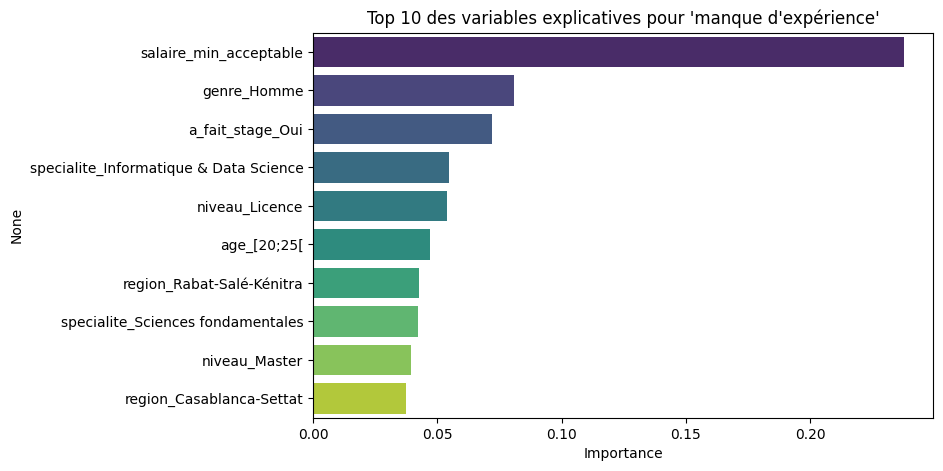

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
df = pd.read_csv('Réponses_nettoyees_et_regroupees.csv')

# 1️⃣ Garder les colonnes utiles
features = ['genre', 'age', 'specialite', 'niveau', 'region', 'a_fait_stage', 'salaire_min_acceptable']
target_cols = ['manque_experience', 'competences_non_adaptees', 'peu_offres', 'salaire_faible']

X = df[features]
y = df[target_cols]

# 2️⃣ Encodage des variables catégorielles
X_encoded = pd.get_dummies(X, drop_first=True)

# 3️⃣ Remplacer les NaN éventuels dans salaire
X_encoded['salaire_min_acceptable'] = X_encoded['salaire_min_acceptable'].fillna(X_encoded['salaire_min_acceptable'].median())

# 4️⃣ Split en train/test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 5️⃣ Modèle Random Forest multilabel
model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
model.fit(X_train, y_train)

# 6️⃣ Prédictions
y_pred = model.predict(X_test)

# 7️⃣ Évaluation
for i, col in enumerate(target_cols):
    print(f"🔍 Résultats pour {col} :")
    print(classification_report(y_test[col], y_pred[:, i]))

# 8️⃣ Importance des variables pour 1 des labels (ex : "manque_experience")
importances = model.estimators_[0].feature_importances_
feat_names = X_encoded.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)[:10]

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Top 10 des variables explicatives pour 'manque d'expérience'")
plt.xlabel("Importance")
plt.show()
